In [135]:
import plotly.graph_objects as plotly
import numpy as np
import matplotlib.pyplot as plt

import json
import scipy.ndimage as sci


2D version of code. Uses a gaussian as a window function to make $\delta_R(x)$

In [136]:
# generate random sphere parameters
spheres = []

# NOTE: modifying JSON ================================
# N=200
# for _ in range(N):
#     sphere = {
#         "cx": float(np.random.rand()),
#         "cy": float(np.random.rand()),
#         "cz": float(np.random.rand()),
#         "sigma": float(np.random.uniform(0.01, 0.11)),
#         "amp": float(np.random.uniform(0.003, 8))
#     }

#     spheres.append(sphere)

# #save to json
# with open("universe_parameters.json", "w") as f:
#     json.dump(spheres, f, indent=4)


# load universe parameters ============================
with open("universe_parameters.json", "r") as f:
    spheres = json.load(f)

#### mini-universe
<small> spherical balls at a random location with some random stddev spreading out and some amplitude determining how large as scalar multiplier

can play around with: stddev, amp and number balls

- amp: max density achievable
- sigma: spread of density

$a \cdot e^{\frac{-r^2}{2 \sigma^2}}$
and $r^2 = (x-x_c)^2+(y-y_c)^2+(z-z_c)^2$

<p style="color: magenta;"> ^.</p>


In [137]:
# forming volume

dim=32 # for now


x = np.linspace(0, 1, dim)
y = np.linspace(0, 1, dim)
z = np.linspace(0, 1, dim)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij') # makes the coordinate arrays for the 3D grid

# box = np.random.normal(0, 0.6, (N, N, N))  # this is the 3D array of values that we want to visualize. 
    # NOTE: gaussian but im not sure what this one was doing

box = np.zeros((dim, dim, dim)) # empty volume of N^3 dimensions

N = len(spheres)

# ===== for random generate ======

# making gaussian spheres

# N = np.random.randint(0,400) # random number of spheres
# print(f"num spheres {N}")

# for _ in range(N):
#     cx,cy,cz=np.random.rand(3) # random values between 0-1 of shape 3
#     # ^this is the mean
#     sigma = np.random.uniform(0.01, 0.1) # random standard deviation between values
#     amp = np.random.uniform(0.003, 8) # random max density - not normalized 

    
#     # add structures to volume
#     blob = amp * np.exp(
#         -(
#             (X - cx)**2 +
#             (Y - cy)**2 +
#             (Z - cz)**2
#         ) / (2 * sigma**2)
#     ) # spheres * stddev across axes, X-cx makes the values between
#       # 0-1 before theyre multiplied by some size

#     box += blob
# print(np.shape(box))
# print(np.ndim(box))



In [138]:
# from json dataset

for s in spheres:

    cx = s["cx"]
    cy = s["cy"]
    cz = s["cz"]
    sigma = s["sigma"]
    amp = s["amp"]

    blob = amp * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * sigma**2)
    )

    box += blob

In [139]:
# make figure

fig = plotly.Figure(data=plotly.Volume(
    x=X.flatten(), # flatten arrays into 1D lists
    y=Y.flatten(),
    z=Z.flatten(),
    value=box.flatten(),
    isomin=0,
    isomax=box.max(),
    opacity=0.08,  # lower = more transparent visually
    surface_count=60 # more rendering
))

# fig.update_layout(template = "plotly_dark")
# fig.show()
# fig.show(renderer="browser")

#### density field

<small>

$N$: total number i think

$n(x)$: how many per voxel, where $x$ is a voxel

$\bar n$: density -> average,
    $\bar n = \frac{\sum{n(x)}}{N}$

$S(x)$: overdensity of field, scalar field,
    $S(x) = \frac{n(x)}{\bar n}-1$
    
- exact avg is =0
- \>0 is overdense
- <0 is underdense

`box[i,j,k]` is a density

`total_per_voxel = new_box.sum(axis=(1,3,5))` is a mass since $m = \int_V \rho(x) dV$ or $m = \sum \rho_{ijk} \Delta V$

In [140]:
new_dim = 4 # fraction of larger volume

# indexing 
middle_box = box.shape[0]//2
# middle_new_box = new_box.shape[0]//2
box = box[middle_box, :, :]
new_box = box.copy()


# calculate density field
def density_field(total_gaussian_sum, N): # 'raw count' and total
    return total_gaussian_sum/N

def overdensity_field(density_field):
    return (density_field/np.mean(density_field)) - 1


for $W(r) = \text{exp}(\frac{-r^2}{2 \sigma^2}), r \leq r_{max}$, their kernel is $W(r) = \frac{W(r)}{\sum_r W(r)}$ (normalized)

<small>

where the default size is $2*\text{radius}+1$ with radius= by default equal to $4*\text{sigma}$

In [141]:
# instead, gaussian filter 

def downsample(box):
    # overdensity_x = overdensity_field(box)
    R = 100 # in grid cells
    return sci.gaussian_filter(box, sigma=R, mode='wrap') # theres a radius= also


overdensity_x = overdensity_field(box)

density_R = downsample(box)
overdensity_R = overdensity_field(density_R)


# will make versions using convolve and direct integration

#### the mark function and density field

<small>

$m(\delta(\bold x), R) = (\frac{1+\delta *}{1+\delta *+ \delta_R(x)})$

$ 1+ \delta_M(\bold x, t) = (1+\delta_X(\bold x, t))m[\delta_R(\bold x)]$


In [142]:
def mark(density_field, d_star=10, p=7): # using aviles's definition
    return ((1+d_star)/(1+d_star+density_field))**p

def marked_density_field(tracer_field, downsampled_field):
    return (1+tracer_field)*mark(downsampled_field)-1


# the density field of the tracers is the original box
tracer_field = box
overdensity_x = overdensity_field(box)

# the mark is 
mx = mark(overdensity_R, d_star=10, p=4)

# the marked density field
dm_x = marked_density_field(overdensity_x, overdensity_R) # overdensity tracer and overdensity of marked downsampled field

In [143]:
# import plotly.graph_objects as go

# # take middle slice
# # slice2d = box[dim//2, :, :]
# slice2d=dm_x

# fig = go.Figure(
#     data=[
#         go.Surface(
#             z=slice2d,
#             x=x
#             y=y
#         )
#     ]
# )

# fig.update_layout(
#     title="marked density field - 2D cross-section",
#     scene=dict(
#         xaxis_title="x",
#         yaxis_title="y",
#         zaxis_title="density"
#     )
# )
# fig.write_html('2d surface plot.html')

# # fig.show(renderer='browser')
# fig.show()

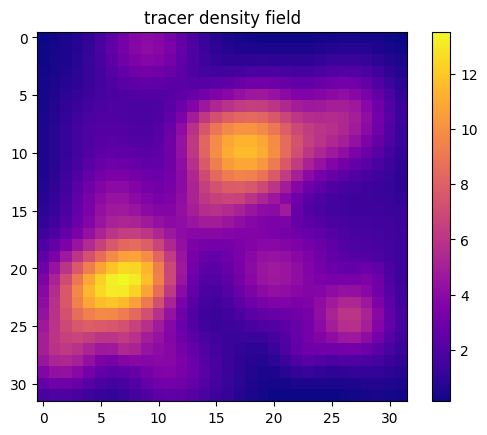

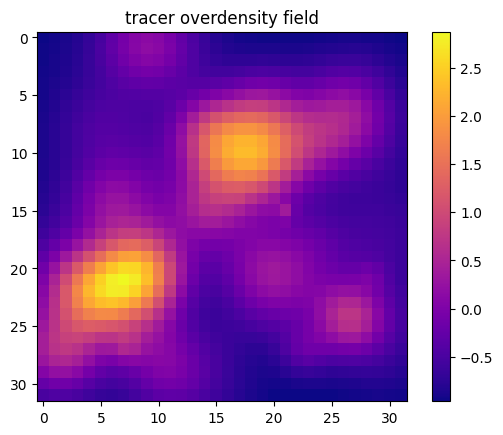

mean of overdensity in entire volume: 5.551115123125783e-17


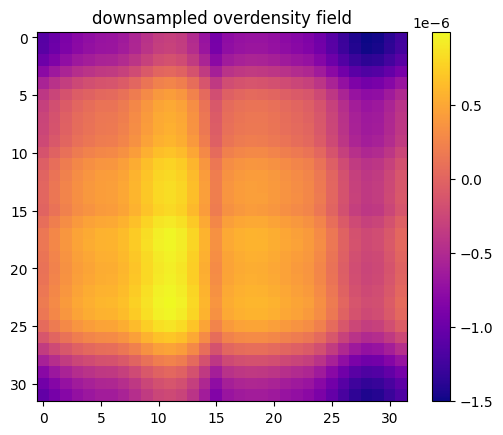

mean of overdensity in entire volume: -2.200930410145574e-17


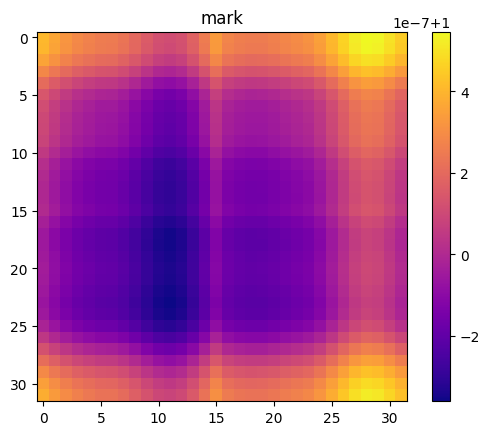

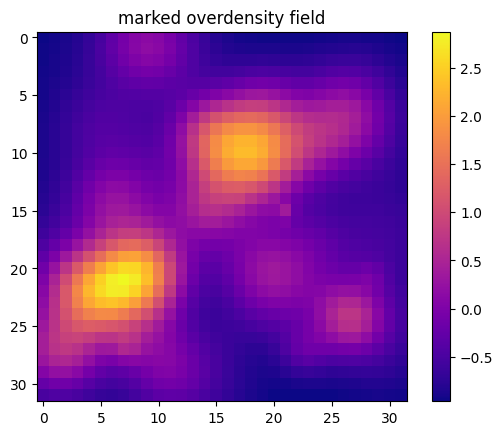

mean of overdensity in entire volume: -1.3712149711520016e-07


In [144]:
# # heatmap showing one layer for visual comparison

# original
plt.imshow(box, cmap='plasma')
plt.colorbar()
plt.title("tracer density field")
plt.savefig("original_density.png")
plt.show()

# # unscaled
# plt.imshow(total_per_voxel[2,:,:], cmap='plasma')
# plt.colorbar()
# plt.title("unscaled")
# plt.show()

# # scaled by volume
# plt.imshow(density_per_voxel[2,:,:], cmap='plasma')
# plt.colorbar()
# plt.title("volume")
# plt.show()

# density field
# plt.imshow(density[2,:,:], cmap='plasma')
# plt.colorbar()
# plt.title("density field")
# plt.show()

# overdensity_field_x
plt.imshow(overdensity_x, cmap='plasma')
plt.colorbar()
plt.title("tracer overdensity field")
plt.savefig("overdensity_x.png")
plt.show()
print(f"mean of overdensity in entire volume: {np.mean(overdensity_x)}")


# overdensity_field_R
plt.imshow(overdensity_R, cmap='plasma')
plt.colorbar()
plt.title("downsampled overdensity field")
plt.show()
plt.savefig("overdesnsity_R.png")
print(f"mean of overdensity in entire volume: {np.mean(overdensity_R)}")

# reshaped overdensity
# reshaped_smooth = np.repeat(np.repeat(np.repeat(overdensity, smaller_dim, axis=0), smaller_dim, axis=1), smaller_dim, axis=2)
# plt.imshow(reshaped_smooth[2,:,:], cmap='plasma')
# plt.colorbar()
# plt.title("reshaped")
# plt.show()
# print(np.shape(reshaped_smooth))

# marked 
plt.imshow(mx, cmap='plasma')
plt.title("mark")
plt.colorbar()
plt.savefig("mark.png")
plt.show()

# marked field
plt.imshow(dm_x, cmap='plasma')
plt.title("marked overdensity field")
plt.colorbar()
plt.savefig("marked_overdensity.png")
plt.show()
print(f"mean of overdensity in entire volume: {np.mean(dm_x)}")


5.551115123125783e-17
-2.200930410145574e-17
-1.3712149711520016e-07
0.9999996394317788
1.0000005464659782
1.0000000000000235


Text(0.5, 1.0, 'marked - tracer')

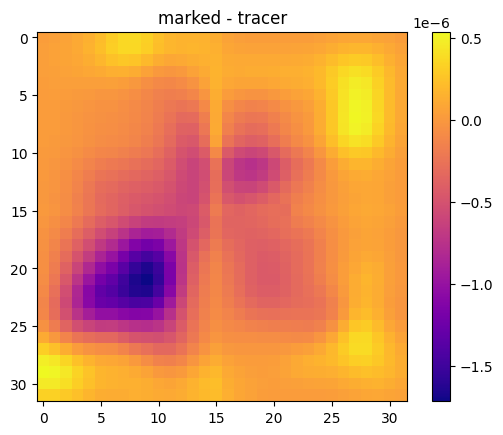

In [145]:
print(np.mean(overdensity_field(box)))
print(np.mean(overdensity_R))
print(np.mean(dm_x))

print(np.min(mx))
print(np.max(mx))
print(np.mean(mx))

difference = dm_x - overdensity_field(box)
plt.imshow(difference, cmap='plasma')
plt.colorbar()
plt.savefig("difference.png")
plt.title("marked - tracer")



In [146]:
print(np.mean(overdensity_x))
print(np.mean(dm_x))

5.551115123125783e-17
-1.3712149711520016e-07
